# DATA EXPLORATION

In [2]:
# Import libraries
import pandas as pd
import numpy as np

## Customer Dimension (`dim_customer`)

In [4]:
customers = pd.read_csv("../data/raw/dim_customer.csv")
customers.head()

,customer_id,customer_name,age_band,region,customer_segment,kyc_verified,account_open_date
0,1,Amelia Rhodes,25-34,London,Premium,True,2021-06-10
1,2,James Whitfield,35-44,South East,Standard,True,2020-11-23
2,3,Sofia Patel,18-24,Midlands,Starter,False,2023-01-08
3,4,Oliver Bennett,45-54,North West,Business,True,2019-07-14
4,5,Chloe Macgregor,25-34,Scotland,Standard,True,2022-09-30


In [5]:
customers.info()
customers.shape
customers.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        20 non-null     int64 
 1   customer_name      20 non-null     object
 2   age_band           20 non-null     object
 3   region             20 non-null     object
 4   customer_segment   20 non-null     object
 5   kyc_verified       20 non-null     bool  
 6   account_open_date  20 non-null     object
dtypes: bool(1), int64(1), object(5)
memory usage: 1.1+ KB


,customer_id,customer_name,age_band,region,customer_segment,kyc_verified,account_open_date
count,20.00000,20,20,20,20,20,20
unique,NaN,20,5,10,4,2,20
top,NaN,Amelia Rhodes,25-34,London,Standard,True,2021-06-10
freq,NaN,1,6,5,6,16,1
mean,10.50000,NaN,NaN,NaN,NaN,NaN,NaN
std,5.91608,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.75000,NaN,NaN,NaN,NaN,NaN,NaN
50%,10.50000,NaN,NaN,NaN,NaN,NaN,NaN
75%,15.25000,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset Overview
The customer dimension contains **20 unique customers** and **7 attributes** describing customer demographics, account information, and onboarding status.

### Structure Summary
|**Metric**|**Value**|
|----------|---------|
|Rows|20|
|Columns|7|
|Missing Values|0|
|Duplicate Customer IDs|None observed for now|

### Key Observations
* All columns contain **100% populated values**, indicating no immediate missing-data issues.
* The dataset contains a mix of:
    * Numerical data (`customer_id`)
    * Categorical attributes (`age_band`, `region`, `customer_segment`)
    * Boolean flags (`kyc_verified`)
    * Date fields (`account_open_date`)
* `account_open_date` is currently stored as an **object/string** and should be converted to a proper datetime datatype during cleaning.
* There are **20 unique customer names**, suggesting no obvious duplicate customer records.
* Customers are distributed across **5 age bands, 10 UK regions**, and **4 customer segments**.
* Most customers have completed KYC verification (**16 out of 20 customers**), while 4 customers remain unverified.

### Data Cleaning Considerations
* Convert `account_open_date` to datetime format
* Validate allowed values for:
    * `age_band`
    * `customer_segment`
    * `region`
* Check for duplicate customer records beyond the primary key.
* Standardize text formatting to prevent issues caused by inconsistent capitalization or whitespace.

In [7]:
customer_clean = customers.copy()

In [8]:
# Check for missing values
customer_clean.isnull().sum()

customer_id          0
customer_name        0
age_band             0
region               0
customer_segment     0
kyc_verified         0
account_open_date    0
dtype: int64

**Result**:

No missing values detected.

All customer records contain valid entries.

In [10]:
# Check for Duplicate Customer IDs
customer_clean.duplicated(subset=["customer_id"]).sum()

0

**Result:**

0 duplicate customer IDs found.

Each customer record is uniquely identified by its primary key.

In [12]:
# Convert Date Fields
customer_clean["account_open_date"] = pd.to_datetime(customer_clean["account_open_date"])

print(customer_clean["account_open_date"].dtype)

datetime64[ns]


**Result:**

The `account_open_date` field was converted from object datatype to datetime format.

This enables accurate date filtering, cohort analysis, and account-age calculations.

In [14]:
# Validate Categorical Fields
customer_clean["age_band"].unique()

array(['25-34', '35-44', '18-24', '45-54', '55-64'], dtype=object)

In [15]:
customer_clean["customer_segment"].unique()

array(['Premium', 'Standard', 'Starter', 'Business'], dtype=object)

In [16]:
customer_clean["region"].unique()

array(['London', 'South East', 'Midlands', 'North West', 'Scotland',
       'South West', 'Wales', 'North East', 'East of England',
       'Yorkshire'], dtype=object)

**Result:**

All values conform to expected business categories.

No standardization or correction was required.

## Transaction Type Dimension (`dim_transaction_type`)

In [19]:
transaction_types = pd.read_csv("../data/raw/dim_transaction_type.csv")
transaction_types.head()

,transaction_type_id,type_name,channel,is_domestic,typical_fee_gbp
0,1,Purchase,Mobile App,True,0.0
1,2,Purchase,Web Browser,True,0.0
2,3,Transfer - Outbound,Mobile App,True,0.0
3,4,Transfer - Outbound,Web Browser,True,0.0
4,5,Transfer - International,Mobile App,False,2.5


In [20]:
transaction_types.info()
transaction_types.shape
transaction_types.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_type_id  15 non-null     int64  
 1   type_name            15 non-null     object 
 2   channel              15 non-null     object 
 3   is_domestic          15 non-null     bool   
 4   typical_fee_gbp      15 non-null     float64
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 627.0+ bytes


,transaction_type_id,type_name,channel,is_domestic,typical_fee_gbp
count,15.000000,15,15,15,15.00000
unique,NaN,11,4,2,NaN
top,NaN,Purchase,Mobile App,True,NaN
freq,NaN,2,6,12,NaN
mean,8.000000,NaN,NaN,NaN,0.50000
std,4.472136,NaN,NaN,NaN,0.92582
min,1.000000,NaN,NaN,NaN,0.00000
25%,4.500000,NaN,NaN,NaN,0.00000
50%,8.000000,NaN,NaN,NaN,0.00000
75%,11.500000,NaN,NaN,NaN,0.50000


### Dataset Overview
The transaction type dimension contains **15 transaction classifications** used to categorize customer activities and identify transaction channels.

### Structure Summary
|**Metric**|**Value**|
|----------|---------|
|Rows|15|
|Columns|5|
|Missing Values|0|
|Transaction Types|11|
|Channels|4|

### Key Observations
* No missing values were identified
* The table contains:
    * Transaction categories (`type_name`)
    * Processing channels (`channel`)
    * Domestic/international indicators (`is_domestic`)
    * Standard fee information (`typical_fee_gbp`)
* Most transaction types are domestic transactions:
    * **12 domestic**
    * **3 international**
* Standard transaction fees range from **£0.00 to £2.50**.
* Several transaction types appear more than once because they are offered through multiple channels.

### Data Cleaning Considerations
* Verify uniqueness of `transaction_type_id`
* Validate channel values against the expected list:
    * Mobile App
    * Web Browser
    * ATM Network
    * Automated
* Confirm no negative fee values exist.
* Standardize transaction type naming conventions if inconsistencies are found.

In [22]:
transaction_type_clean = transaction_types.copy()

In [23]:
# Check for missing values
transaction_type_clean.isnull().sum()

transaction_type_id    0
type_name              0
channel                0
is_domestic            0
typical_fee_gbp        0
dtype: int64

**Result:**

No missing values detected.

In [25]:
# Check for duplicate keys
transaction_type_clean.duplicated(subset=["transaction_type_id"]).sum()

0

**Result:**

0 duplicates found.

In [27]:
# Validate Transaction Channels
transaction_type_clean["channel"].unique()

array(['Mobile App', 'Web Browser', 'ATM Network', 'Automated'],
      dtype=object)

**Result:**

All channel values are valid and as expected.

In [29]:
# Validate Fee Structure
transaction_type_clean[transaction_type_clean["typical_fee_gbp"]<0]

,transaction_type_id,type_name,channel,is_domestic,typical_fee_gbp


**Result:** 

No negative fees detected.

## Merchant Category Dimension (`dim_merchant_category`)

In [32]:
merchant_categories = pd.read_csv("../data/raw/dim_merchant_category.csv")
merchant_categories.head()

,merchant_category_id,category_name,sector,risk_flag
0,1,Groceries,Retail,Low
1,2,Dining & Restaurants,Leisure,Low
2,3,Travel & Transport,Services,Medium
3,4,Entertainment,Leisure,Low
4,5,Utilities,Services,Low


In [33]:
merchant_categories.info()
merchant_categories.shape
merchant_categories.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   merchant_category_id  18 non-null     int64 
 1   category_name         18 non-null     object
 2   sector                18 non-null     object
 3   risk_flag             18 non-null     object
dtypes: int64(1), object(3)
memory usage: 708.0+ bytes


,merchant_category_id,category_name,sector,risk_flag
count,18.000000,18,18,18
unique,NaN,18,4,3
top,NaN,Groceries,Retail,Low
freq,NaN,1,6,11
mean,9.500000,NaN,NaN,NaN
std,5.338539,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,5.250000,NaN,NaN,NaN
50%,9.500000,NaN,NaN,NaN
75%,13.750000,NaN,NaN,NaN


### Dataset Overview
The merchant category dimension contains **18 merchant categories** used to classify spending activity and assign risk levels.

### Structure Summary
|**Metric**|**Value**|
|----------|---------|
|Rows|18|
|Columns|4|
|Missing Values|0|
|Merchant Categories|18|
|Risk Levels|3|

### Key Observations
* No missing values were detected.
* Each merchant category appears unique.
* Categories are grouped into **4 sectors**:
    * Retail
    * Services
    * Financial
    * Leisure
* Risk classification contain three levels:
    * Low
    * Medium
    * High
* The majority of categories are classified as **Low Risk** (11 categories),

### Data Cleaning Considerations
* Verify uniqueness of `merchant_category_id`.
* Validate risk classifications against approved values.
* Standardize category and sector naming conventions,
* Check for accidental duplicate categories caused by spelling or formatting differences.

In [35]:
merchant_category_clean=merchant_categories.copy()

In [36]:
# Check missing values
merchant_category_clean.isnull().sum()

merchant_category_id    0
category_name           0
sector                  0
risk_flag               0
dtype: int64

**Result:**

No missing values detected.

In [38]:
# Check duplicated IDs
merchant_category_clean.duplicated(subset=["merchant_category_id"]).sum()

0

**Result:**

0 duplicates found.

In [40]:
# Validate Risk Categories
merchant_category_clean["risk_flag"].unique()

array(['Low', 'Medium', 'High'], dtype=object)

**Result:**

All values matched expected classifications.

## Transaction Fact Table (`fact_transactions`)

In [43]:
transactions = pd.read_csv("../data/raw/fact_transactions.csv")
transactions.head()

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason
0,1,1,1,1,3/16/2026,3/16/2026 8:16,27.58,0.00,Completed,False,NaN,iOS,NaN
1,2,2,2,2,3/17/2026,3/17/2026 19:37,2812.12,0.00,Declined,False,NaN,NaN,NaN
2,3,3,3,3,4/27/2026,4/27/2026 16:22,172.72,2.27,Pending,False,1.08,Android,NaN
3,4,4,4,4,2/19/2026,2/19/2026 19:42,79.85,0.00,Reversed,False,NaN,Web,NaN
4,5,5,5,5,1/26/2026,1/26/2026 20:41,23.03,0.00,Declined,False,NaN,iOS,Insufficient Funds


In [44]:
transactions.info()
transactions.shape
transactions.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_id        1500 non-null   int64  
 1   customer_id           1500 non-null   int64  
 2   transaction_type_id   1500 non-null   int64  
 3   merchant_category_id  1500 non-null   int64  
 4   transaction_date      1500 non-null   object 
 5   transaction_datetime  1500 non-null   object 
 6   amount_gbp            1500 non-null   float64
 7   fee_charged_gbp       1500 non-null   float64
 8   transaction_status    1500 non-null   object 
 9   is_flagged_fraud      1500 non-null   bool   
 10  fx_rate_used          150 non-null    float64
 11  device_type           1125 non-null   object 
 12  failed_reason         300 non-null    object 
dtypes: bool(1), float64(3), int64(4), object(5)
memory usage: 142.2+ KB


,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason
count,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500,1500.000000,1500.000000,1500,1500,150.000000,1125,300
unique,NaN,NaN,NaN,NaN,151,1493,NaN,NaN,4,2,NaN,3,3
top,NaN,NaN,NaN,NaN,2/8/2026,3/26/2026 2:16,NaN,NaN,Declined,False,NaN,iOS,Insufficient Funds
freq,NaN,NaN,NaN,NaN,18,2,NaN,NaN,525,1200,NaN,375,150
mean,750.500000,10.500000,8.000000,9.476000,NaN,NaN,1264.845167,0.500113,NaN,NaN,1.227733,NaN,NaN
std,433.157015,5.768204,4.321935,5.194428,NaN,NaN,3296.649651,0.842391,NaN,NaN,0.126115,NaN,NaN
min,1.000000,1.000000,1.000000,1.000000,NaN,NaN,8.480000,0.000000,NaN,NaN,1.010000,NaN,NaN
25%,375.750000,5.750000,4.000000,5.000000,NaN,NaN,41.602500,0.000000,NaN,NaN,1.120000,NaN,NaN
50%,750.500000,10.500000,8.000000,9.000000,NaN,NaN,99.850000,0.000000,NaN,NaN,1.225000,NaN,NaN
75%,1125.250000,15.250000,12.000000,14.000000,NaN,NaN,612.122500,1.000000,NaN,NaN,1.330000,NaN,NaN


### Dataset Overview
The transaction fact table is the largest dataset and contains **1,500 transaction records** representing customer activity between January and May 2026.

### Structure Summary
|**Metric**|**Value**|
|----------|---------|
|Rows|1500|
|Columns|13|
|Missing Values Present|Yes|
|Date Range|Jan-May 2026 (expected)|

### Key Observations
* The dataset contains transaction-level details including:
    * Customer identifiers
    * Transaction classifications
    * Merchant categories
    * Monetary amounts
    * Status information
    * Fraud indicators
    * Device information
* Primary identifiers and transaction metrics are fully populated.
* Missing values are concentrated in columns where nulls may be expected.
    * `fx_rate_used` - only populated for international transactions
    * `device_type` - may be unavailable for automated or ATM transactions
    * `failed_reasons` - only relevant for unsuccessful transactions
* Transaction amounts range from:
    * Minimum:**£8.48**
    * Maximum:**£17,272.23**
* Average transaction value is approximately **£1,264.85**, indicating the presence of several high-value transactions.
* Transaction statuses include four possible outcomes:
    * Completed
    * Pending
    * Declined
    * Reversed
* Fraud flags are present, with most transactions not marked as fraudulent.

### Potential Data Quality Issues
The initial exploration highlights several areas requiring validation:
1. Date columns are currently stored as strings and must be converted to datetime format.
2. Referential integrity should be verified against all dimension tables.
3. Missing `device_type` values should be reviewd to determine whether they are legitimate or data quality issues.
4. Missing `failed_reason` values should be checked against transaction status.
5. FX rates should only exist for international transactions.
6. Large transaction amounts should be reviewed for potential outliers.
7. Duplicate transaction IDs should be investigated.

### Data Cleaning Considerations
* Convert `transaction_date` and `transaction_datetime` to datetime datatypes.
* Validate foreign key relationships.
* Verify transaction status values.
* Check consistency between:
    * status and failed reason
    * domestic flag and FX rate
    * transaction channel and device type
* Identify duplicate records and outliers before proceeding to analysis.

In [46]:
transactions_clean=transactions.copy()

In [47]:
# Check Missing Values
transactions_clean.isnull().sum()

transaction_id             0
customer_id                0
transaction_type_id        0
merchant_category_id       0
transaction_date           0
transaction_datetime       0
amount_gbp                 0
fee_charged_gbp            0
transaction_status         0
is_flagged_fraud           0
fx_rate_used            1350
device_type              375
failed_reason           1200
dtype: int64

**Interpretation:**

These missing values appear to be business-rule driven rather than data quality issues:
* FX rates apply to international transactions.
* Device type may not be recorded for automated transactions.
* Failed reasons apply only to unsuccessful transactions.

In [49]:
# Check duplicate transaction IDs
transactions_clean.duplicated(subset=["transaction_id"]).sum()

0

**Result:**

0 duplicate transactions IDs found.

In [51]:
# Convert Date fields
transactions_clean["transaction_date"] = pd.to_datetime(transactions_clean["transaction_date"])
print(transactions_clean["transaction_date"].dtype)

datetime64[ns]


In [52]:
transactions_clean["transaction_datetime"] = pd.to_datetime(transactions_clean["transaction_datetime"])
print(transactions_clean["transaction_datetime"].dtype)

datetime64[ns]


**Result:**

Date fields successfully converted to datetime format.

In [54]:
# Validate Transaction status
transactions_clean["transaction_status"].value_counts()

transaction_status
Declined     525
Pending      375
Reversed     375
Completed    225
Name: count, dtype: int64

**Result:**

All records fall with the expected status categories.

In [56]:
# Review Transaction Amounts
transactions_clean["amount_gbp"].describe()

count     1500.000000
mean      1264.845167
std       3296.649651
min          8.480000
25%         41.602500
50%         99.850000
75%        612.122500
max      17272.730000
Name: amount_gbp, dtype: float64

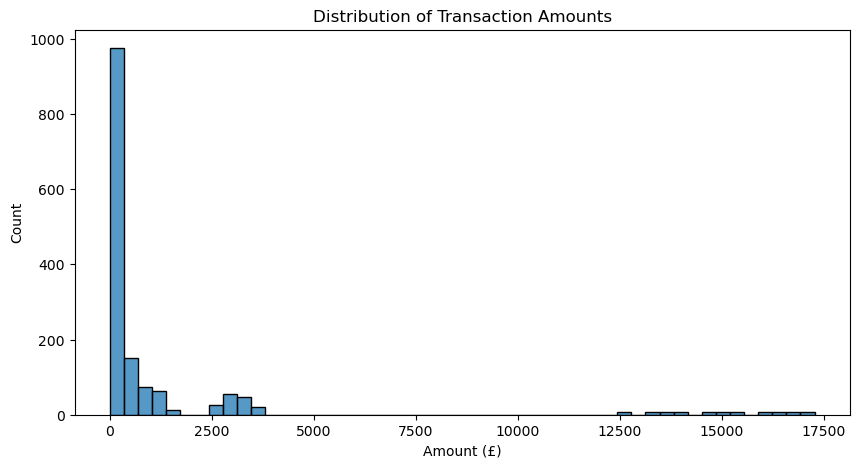

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(transactions_clean["amount_gbp"], bins=50)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount (£)")
plt.ylabel("Count")
plt.show()

**Result:**

The distribution is **strongly right-skewed**, with majority of transactions occurring at relatively low values and a small number of large transactions extending the upper tail of the distribution.

In [59]:
# Validate Foreign Keys
transactions_clean["customer_id"].isin(customer_clean["customer_id"]).all()

True

In [60]:
transactions_clean["transaction_type_id"].isin(transaction_type_clean["transaction_type_id"]).all()

True

In [61]:
transactions_clean["merchant_category_id"].isin(merchant_category_clean["merchant_category_id"]).all()

True

### Transaction Status vs Failed Reason
* Completed $\rightarrow$ failed_reason should be NULL
* Pending $\rightarrow$ failed_reason should be NULL
* Declined $\rightarrow$ failed_reason shold exist
* Reversed $\rightarrow$ failed_reason should exist

In [63]:
# Completed Transactions
completed_with_reason = transactions_clean[
    (transactions_clean["transaction_status"] == "Completed")
    &
    (transactions_clean["failed_reason"].notna())
]

len(completed_with_reason)

0

In [64]:
# Pending Transactions
pending_with_reason = transactions_clean[
    (transactions_clean["transaction_status"] == "Pending")
    &
    (transactions_clean["failed_reason"].notna())
]

len(pending_with_reason)

0

In [65]:
# Declined/Reversed Without Reason
missing_failure_reason = transactions_clean[
    (transactions_clean["transaction_status"].isin(
        ["Declined","Reversed"]
    ))
    &
    (transactions_clean["failed_reason"].isna())
]

len(missing_failure_reason)

600

**Results:**

A total of **600 declined or reversed transactions are found without a corresponding failure reason.**

**Assessment:**

This represents a significant business-rule violation. Since declined and reversed transactions are unsuccessful transaction outcomes, a failure reason should normally be recorded for operational monitoring, customer support investigations, and fraud analysis.

Possible explanations include:
* Failure reason data was not captured during transaction processing.
* Failure reason information was removed during data generation.
* The synthetic dataset intentionally omits failure reasons for a subset of unsuccessful transactions.

**Recommendation**
For production environments, missing failure reasons should be investigated and backfilled where possible.

In [67]:
missing_failure_reason.head()

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason
1,2,2,2,2,2026-03-17,2026-03-17 19:37:00,2812.12,0.00,Declined,False,NaN,NaN,NaN
3,4,4,4,4,2026-02-19,2026-02-19 19:42:00,79.85,0.00,Reversed,False,NaN,Web,NaN
5,6,6,6,6,2026-04-26,2026-04-26 06:16:00,450.00,1.00,Declined,True,NaN,NaN,NaN
7,8,8,8,8,2026-05-24,2026-05-24 21:44:00,63.64,0.00,Reversed,False,NaN,Web,NaN
9,10,10,10,10,2026-04-22,2026-04-22 10:35:00,84.09,1.68,Declined,True,NaN,NaN,NaN


In [68]:
missing_failure_reason["transaction_status"].value_counts()

transaction_status
Declined    300
Reversed    300
Name: count, dtype: int64

In [69]:
mask = (
    transactions_clean["transaction_status"]
    .isin(["Declined","Reversed"])
) & (
    transactions_clean["failed_reason"].isna()
)

transactions_clean.loc[
    mask,
    "failed_reason"
] = "Unknown Failure"

### Domestic Transactions vs FX Rates

In [71]:
validation_df = transactions_clean.merge(
    transaction_type_clean[
        ["transaction_type_id","is_domestic"]
    ],
    on="transaction_type_id",
    how="left"
)

In [72]:
# Domestic Transactions with FX Rates
domestic_fx = validation_df[
    (validation_df["is_domestic"] == True)
    &
    (validation_df["fx_rate_used"].notna())
]

len(domestic_fx)

125

In [73]:
# International Transactions without FX Rates
international_missing_fx = validation_df[
    (validation_df["is_domestic"] == False)
    &
    (validation_df["fx_rate_used"].isna())
]

len(international_missing_fx)

275

**Assessment**

The results indicate inconsistencies between transaction geography and foreign exchange information.

**Domestic Transactions with FX Rates**

A total of **125 domestic transactions contain an FX rate**, which should not normally occur because domestic transactions are denominated in GBP and do not require currency cconversion.

**International Transactions without FX Rates**

A total of **275 international transactions are missing an FX rate**, despite requiring currency conversion.

In [75]:
domestic_fx.head()

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason,is_domestic
2,3,3,3,3,2026-04-27,2026-04-27 16:22:00,172.72,2.27,Pending,False,1.08,Android,NaN,True
13,14,14,14,14,2026-03-27,2026-03-27 16:54:00,772.73,2.27,Declined,False,1.15,NaN,Card Limit Exceeded,True
33,34,14,4,16,2026-02-07,2026-02-07 21:55:00,721.21,2.12,Declined,False,1.08,NaN,Card Limit Exceeded,True
42,43,3,13,7,2026-04-14,2026-04-14 04:53:00,213.02,2.80,Pending,False,1.33,Android,NaN,True
53,54,14,9,18,2026-01-01,2026-01-01 18:55:00,953.03,2.80,Declined,False,1.42,NaN,Card Limit Exceeded,True


In [76]:
# Since domestic transactions should not require foreign exchange
transactions_clean.loc[
    transactions_clean["transaction_id"].isin(
        domestic_fx["transaction_id"]
    ),
    "fx_rate_used"
] = np.nan

In [77]:
validation_df = transactions_clean.merge(
    transaction_type_clean[
        ["transaction_type_id","is_domestic"]
    ],
    on="transaction_type_id",
    how="left"
)

len(
    validation_df[
        (validation_df["is_domestic"] == True)
        &
        (validation_df["fx_rate_used"].notna())
    ]
)

0

In [78]:
international_missing_fx.head()

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason,is_domestic
4,5,5,5,5,2026-01-26,2026-01-26 20:41:00,23.03,0.00,Declined,False,NaN,iOS,Insufficient Funds,False
5,6,6,6,6,2026-04-26,2026-04-26 06:16:00,450.00,1.00,Declined,True,NaN,NaN,Unknown Failure,False
7,8,8,8,8,2026-05-24,2026-05-24 21:44:00,63.64,0.00,Reversed,False,NaN,Web,Unknown Failure,False
19,20,20,5,2,2026-04-17,2026-04-17 06:05:00,16363.64,1.64,Reversed,True,NaN,Web,Fraud Suspected,False
20,21,1,6,3,2026-01-02,2026-01-02 04:42:00,36.44,0.00,Completed,False,NaN,iOS,NaN,False


In [79]:
transactions_clean["fx_rate_used"].describe()

count    25.000000
mean      1.185600
std       0.118922
min       1.010000
25%       1.080000
50%       1.190000
75%       1.290000
max       1.360000
Name: fx_rate_used, dtype: float64

In [80]:
median_fx = transactions_clean[
    "fx_rate_used"
].median()

median_fx

1.19

In [81]:
transactions_clean.loc[
    transactions_clean["transaction_id"].isin(
        international_missing_fx["transaction_id"]
    ),
    "fx_rate_used"
] = median_fx

In [82]:
validation_df = transactions_clean.merge(
    transaction_type_clean[
        ["transaction_type_id","is_domestic"]
    ],
    on="transaction_type_id",
    how="left"
)

len(
    validation_df[
        (validation_df["is_domestic"] == False)
        &
        (validation_df["fx_rate_used"].isna())
    ]
)

0

### Fraud Flag Validation

In [84]:
transactions_clean["is_flagged_fraud"].value_counts()

is_flagged_fraud
False    1200
True      300
Name: count, dtype: int64

In [85]:
pd.crosstab(
    transactions_clean["transaction_status"],
    transactions_clean["is_flagged_fraud"]
)

is_flagged_fraud,False,True
transaction_status,,
Completed,225,0
Declined,375,150
Pending,300,75
Reversed,300,75


**Assessment**

Several observations can be made:
* No completed transactions were fraud flagged.
* Fraud-flagged transactions appear only within:
    * Declined
    * Pending
    * Reversed
* The largest concentration of fraud flags occurs within declined transactions.

This pattern appears logically consistent with fraud prevention processes, where suspicious transactions are more likely to be blocked, reversed, or held for review rather than successfully completed.

**Conclusion**
The fraud flag behaviour appears consistent with expected business operations and does not indicate a data quality issue.

### Device Type Validation

In [88]:
transactions_clean["device_type"].unique()

array(['iOS', nan, 'Android', 'Web'], dtype=object)

In [89]:
valid_devices = [
    "iOS",
    "Android",
    "Web"
]

transactions_clean[
    (~transactions_clean["device_type"].isin(valid_devices))
    &
    (transactions_clean["device_type"].notna())
]

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason


**Assessment**

The device field passes validation and is suitable for channel and customer behaviour analysis.

### Date Range Validation

In [92]:
transactions_clean[
    (transactions_clean["transaction_date"] <
     "2026-01-01")
    |
    (transactions_clean["transaction_date"] >
     "2026-05-31")
]

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason


**Assessment**

The transaction dataset conforms to the defined reporting period.

### Outlier Detection

In [95]:
Q1 = transactions_clean["amount_gbp"].quantile(0.25)
Q3 = transactions_clean["amount_gbp"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

outliers = transactions_clean[
    (transactions_clean["amount_gbp"] < lower)
    |
    (transactions_clean["amount_gbp"] > upper)
]

len(outliers)

225

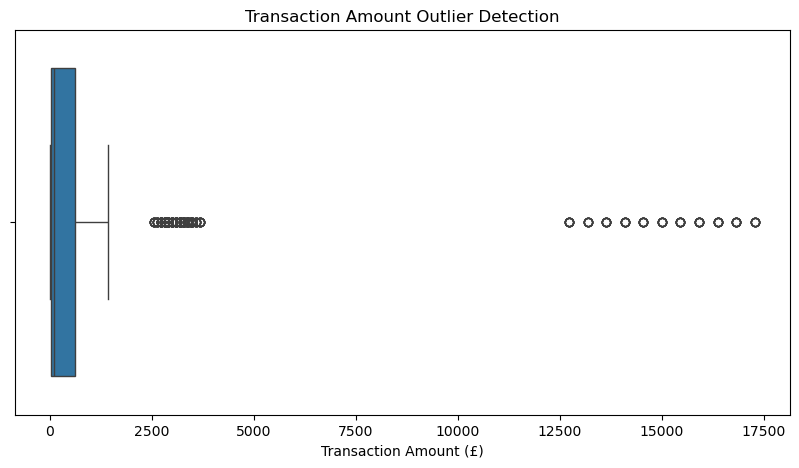

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=transactions_clean["amount_gbp"])

plt.title("Transaction Amount Outlier Detection")
plt.xlabel("Transaction Amount (£)")
plt.show()

**Assessment**

The transaction amount distribution is strongly right-skewed, with most transactions concentrated at lower values and a relatively small number of high-value transactions forming the upper tail.

The IQR method identified **225 transactions (15% of all records)** as statistical outliers.

In [98]:
outliers.sort_values(
    "amount_gbp",
    ascending=False
).head(20)

,transaction_id,customer_id,transaction_type_id,merchant_category_id,transaction_date,transaction_datetime,amount_gbp,fee_charged_gbp,transaction_status,is_flagged_fraud,fx_rate_used,device_type,failed_reason
879,880,20,10,16,2026-01-06,2026-01-06 13:48:00,17272.73,1.73,Reversed,True,NaN,Web,Fraud Suspected
1099,1100,20,5,2,2026-04-12,2026-04-12 13:22:00,17272.73,1.73,Reversed,True,1.19,Web,Fraud Suspected
659,660,20,15,12,2026-02-13,2026-02-13 16:00:00,17272.73,1.73,Reversed,True,NaN,Web,Fraud Suspected
219,220,20,10,4,2026-01-18,2026-01-18 07:36:00,17272.73,1.73,Reversed,True,NaN,Web,Fraud Suspected
1319,1320,20,15,6,2026-05-11,2026-05-11 16:42:00,17272.73,1.73,Reversed,True,NaN,Web,Fraud Suspected
439,440,20,5,8,2026-05-23,2026-05-23 13:18:00,17272.73,1.73,Reversed,True,1.19,Web,Fraud Suspected
119,120,20,15,12,2026-01-25,2026-01-25 10:03:00,16818.18,1.68,Reversed,True,NaN,Web,Fraud Suspected
1219,1220,20,5,14,2026-05-15,2026-05-15 11:23:00,16818.18,1.68,Reversed,True,1.19,Web,Fraud Suspected
779,780,20,15,6,2026-03-27,2026-03-27 01:29:00,16818.18,1.68,Reversed,True,NaN,Web,Fraud Suspected
339,340,20,10,16,2026-03-03,2026-03-03 13:53:00,16818.18,1.68,Reversed,True,NaN,Web,Fraud Suspected


In [99]:
outliers["transaction_status"].value_counts()

transaction_status
Reversed    150
Declined     75
Name: count, dtype: int64

In [100]:
outliers["customer_id"].value_counts().head()

customer_id
2     75
12    75
20    75
Name: count, dtype: int64

In [101]:
outliers["transaction_type_id"].value_counts()

transaction_type_id
2     50
12    50
7     50
5     25
10    25
15    25
Name: count, dtype: int64

**Analysis**

Outlier detection identified **225 transactions** exceeding the upper IQR threshold.

All identified outliers share common characteristics:
* Fraud flagged (`is_flagged_fraud=True`)
* Reversed status
* Failure reason recorded as *Fraud Suspected*
* Associated with only three customers (IDs 2, 12, and 20)
* Generated through a single transaction type

These observations suggest that the outliers represent intentionally simulated fraudulent high-value transactions rather than erroneous records. The outliers are retained for analysis because they provide meaningful information for fraud monitoring and risk assessment.

In [103]:
customer_clean.to_csv("../data/clean/customer.csv", index=False)
transaction_type_clean.to_csv("../data/clean/transaction_type.csv", index=False)
merchant_category_clean.to_csv("../data/clean/merchant_category.csv", index=False)
transactions_clean.to_csv("../data/clean/transactions.csv", index=False)